In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
news = pd.read_csv('data/newsData/raw_analyst_ratings.csv')

In [3]:
print(news.shape)

(1407328, 6)


In [4]:
print(news.columns.tolist())

['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']


In [5]:
news.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [6]:
aapl = pd.read_csv('data/newsData/yfinance_data/Data/AAPL.csv')

In [7]:
print(aapl.shape)
print(aapl.columns.tolist())
aapl.head()

(3774, 6)
['Date', 'Close', 'High', 'Low', 'Open', 'Volume']


,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [8]:
aapl = pd.read_csv('data/newsData/yfinance_data/Data/AAPL.csv')
print(aapl.shape)
print(aapl.columns.tolist())
aapl.head()

(3774, 6)
['Date', 'Close', 'High', 'Low', 'Open', 'Volume']


,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [9]:
news['stock'].unique()


<StringArray>
[   'A',   'AA',  'AAC', 'AADR',  'AAL', 'AAMC', 'AAME',  'AAN', 'AAOI',
 'AAON',
 ...
 'ZOES', 'ZPIN',  'ZQK',  'ZSL', 'ZSPH',  'ZTR',  'ZTS',   'ZU', 'ZUMZ',
   'ZX']
Length: 6204, dtype: str

In [13]:
news['date'] = pd.to_datetime(news['date'], utc=True, errors='coerce')
print(f"Earliest date: {news['date'].min()}")
print(f"Latest date: {news['date'].max()}")

Earliest date: 2011-04-28 01:01:48+00:00
Latest date: 2020-06-11 21:12:35+00:00


In [14]:
print(news['date'].head(10))

0   2020-06-05 14:30:54+00:00
1   2020-06-03 14:45:20+00:00
2   2020-05-26 08:30:07+00:00
3   2020-05-22 16:45:06+00:00
4   2020-05-22 15:38:59+00:00
5   2020-05-22 15:23:25+00:00
6   2020-05-22 13:36:20+00:00
7   2020-05-22 13:07:04+00:00
8   2020-05-22 12:37:59+00:00
9   2020-05-22 12:06:17+00:00
Name: date, dtype: datetime64[us, UTC]


In [15]:
aapl['Date'] = pd.to_datetime(aapl['Date'])
print(f"AAPL - Earliest: {aapl['Date'].min()}")
print(f"AAPL - Latest: {aapl['Date'].max()}")

AAPL - Earliest: 2009-01-02 00:00:00
AAPL - Latest: 2023-12-29 00:00:00


In [16]:
news['stock'].value_counts().head(20)

stock
MRK     3333
MS      3238
NVDA    3146
MU      3142
QQQ     3106
NFLX    3028
M       3025
EBAY    3018
GILD    2968
VZ      2966
QCOM    2941
JNJ     2928
DAL     2926
BABA    2858
KO      2797
AA      2739
EWU     2702
ORCL    2701
FDX     2629
HD      2612
Name: count, dtype: int64

In [17]:
news['publisher'].value_counts().head(15)

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313
Benzinga_Newsdesk     19410
Zacks                 19390
Jayson Derrick        19050
Name: count, dtype: int64

In [18]:
print("Missing values:")
print(news.isnull().sum())

Missing values:
Unnamed: 0          0
headline            0
url                 0
publisher           0
date          1351341
stock               0
dtype: int64


In [19]:
news['date_only'] = news['date'].dt.date
daily_volume = news.groupby('date_only').size()
print(daily_volume.head(10))

date_only
2011-04-28    3
2011-04-29    2
2011-04-30    1
2011-05-01    1
2011-05-02    9
2011-05-03    3
2011-05-05    3
2011-05-06    3
2011-05-07    1
2011-05-08    1
dtype: int64


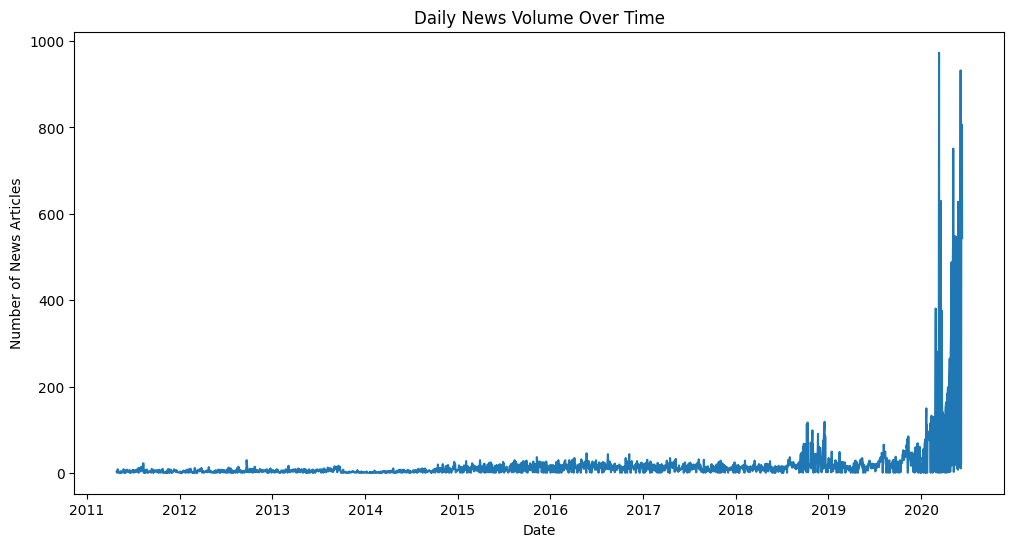

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
daily_volume.plot()
plt.xlabel('Date')
plt.ylabel('Number of News Articles')
plt.title('Daily News Volume Over Time')
plt.show()

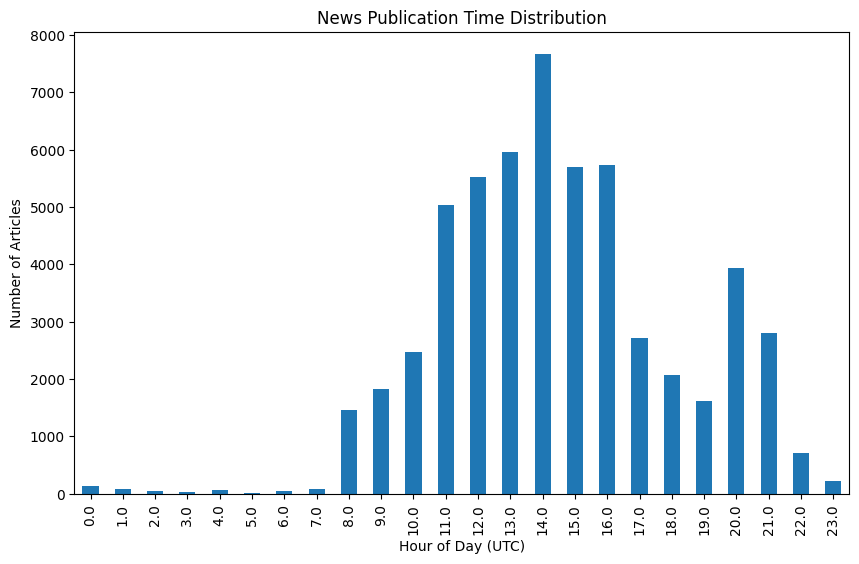

In [21]:
news['hour'] = news['date'].dt.hour
hourly_volume = news.groupby('hour').size()

plt.figure(figsize=(10,6))
hourly_volume.plot(kind='bar')
plt.xlabel('Hour of Day (UTC)')
plt.ylabel('Number of Articles')
plt.title('News Publication Time Distribution')
plt.show()

In [22]:
news['headline_length'] = news['headline'].str.len()
print("Headline Length Statistics:")
print(news['headline_length'].describe())

Headline Length Statistics:
count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64


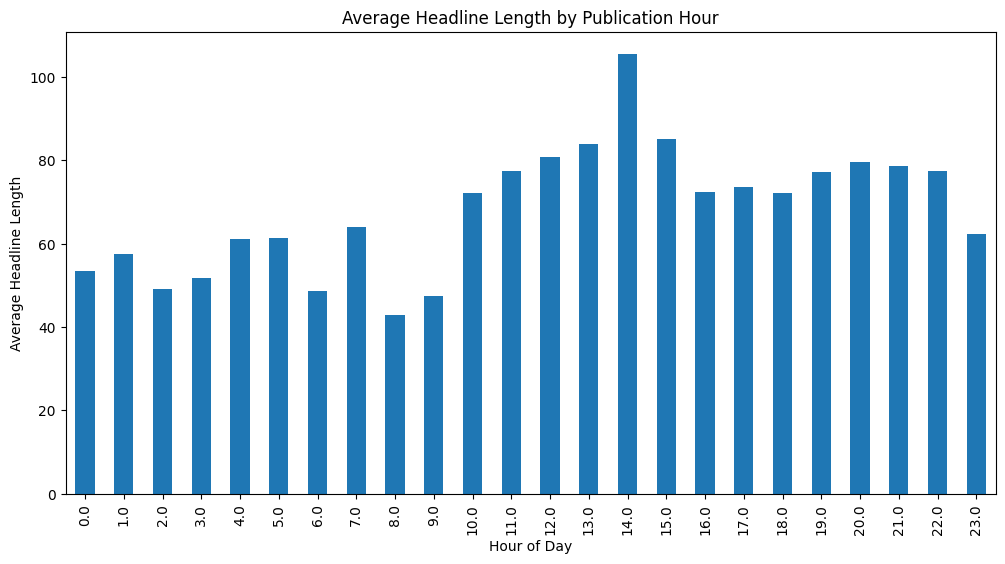

In [23]:
news.groupby('hour')['headline_length'].mean().plot(kind='bar', figsize=(12,6))
plt.xlabel('Hour of Day')
plt.ylabel('Average Headline Length')
plt.title('Average Headline Length by Publication Hour')
plt.show()